# 🤖 Moving Bot Sensor Analysis
## Dataset: `[UPDATE PATH BELOW]` (Bot moving in square path)

**Objective:** Analyze sensor behavior during motion — compare odometry sources,
detect dynamic noise characteristics, and evaluate filter performance under real conditions.

> ⚠️ **UPDATE the `BAG_PATH` in the next cell with your actual moving dataset path!**


## 1. Imports & Data Loading

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import signal, stats
from scipy.fft import rfft, rfftfreq
from scipy.signal import savgol_filter, medfilt, butter, filtfilt, welch, find_peaks
from scipy.ndimage import uniform_filter1d
import pywt
import allantools
from sklearn.ensemble import IsolationForest
from sklearn.linear_model import RANSACRegressor, HuberRegressor
import warnings
warnings.filterwarnings('ignore')

import rosbag2_py
from rclpy.serialization import deserialize_message
from sensor_msgs.msg import Imu, NavSatFix, JointState
from nav_msgs.msg import Odometry

plt.style.use('seaborn-darkgrid')
plt.rcParams.update({
    'figure.figsize': (18, 6), 'font.size': 11,
    'axes.titlesize': 14, 'axes.labelsize': 12,
    'figure.dpi': 100, 'figure.max_open_warning': 0,
})
sns.set_palette("husl")
print("✅ Imports done")

# ──────────────── DATA LOADING ────────────────
# ⚠️ UPDATE THIS PATH
BAG_PATH = '/home/rosdata/rosbags/moving_bot_data_20260410_214010'

reader = rosbag2_py.SequentialReader()
storage_options = rosbag2_py.StorageOptions(uri=BAG_PATH, storage_id='sqlite3')
converter_options = rosbag2_py.ConverterOptions(
    input_serialization_format='cdr', output_serialization_format='cdr')
reader.open(storage_options, converter_options)

imu_data, gps_data, wheel_odom_data = [], [], []
visual_odom_data, lidar_odom_data, joint_data = [], [], []

print("📦 Reading bag file... (this may take a minute)")
while reader.has_next():
    topic, data, t = reader.read_next()
    ts = t / 1e9

    if topic == '/imu/data':
        msg = deserialize_message(data, Imu)
        imu_data.append({
            'time': ts,
            'ax': msg.linear_acceleration.x, 'ay': msg.linear_acceleration.y,
            'az': msg.linear_acceleration.z,
            'gx': msg.angular_velocity.x, 'gy': msg.angular_velocity.y,
            'gz': msg.angular_velocity.z,
            'ox': msg.orientation.x, 'oy': msg.orientation.y,
            'oz': msg.orientation.z, 'ow': msg.orientation.w,
        })
    elif topic == '/gps/fix':
        msg = deserialize_message(data, NavSatFix)
        gps_data.append({
            'time': ts, 'lat': msg.latitude, 'lon': msg.longitude,
            'alt': msg.altitude, 'status': msg.status.status,
        })
    elif topic == '/diff_drive_controller/odom':
        msg = deserialize_message(data, Odometry)
        wheel_odom_data.append({
            'time': ts, 'x': msg.pose.pose.position.x, 'y': msg.pose.pose.position.y,
            'z': msg.pose.pose.position.z,
            'vx': msg.twist.twist.linear.x, 'vy': msg.twist.twist.linear.y,
            'wz': msg.twist.twist.angular.z,
        })
    elif topic == '/odometry/visual':
        msg = deserialize_message(data, Odometry)
        visual_odom_data.append({
            'time': ts, 'x': msg.pose.pose.position.x, 'y': msg.pose.pose.position.y,
            'z': msg.pose.pose.position.z,
            'vx': msg.twist.twist.linear.x, 'vy': msg.twist.twist.linear.y,
            'wz': msg.twist.twist.angular.z,
        })
    elif topic == '/odometry/lidar':
        msg = deserialize_message(data, Odometry)
        lidar_odom_data.append({
            'time': ts, 'x': msg.pose.pose.position.x, 'y': msg.pose.pose.position.y,
            'z': msg.pose.pose.position.z,
            'vx': msg.twist.twist.linear.x, 'vy': msg.twist.twist.linear.y,
            'wz': msg.twist.twist.angular.z,
        })
    elif topic == '/joint_states':
        msg = deserialize_message(data, JointState)
        d = {'time': ts}
        for i, name in enumerate(msg.name):
            if i < len(msg.position): d[f'{name}_pos'] = msg.position[i]
            if i < len(msg.velocity): d[f'{name}_vel'] = msg.velocity[i]
        joint_data.append(d)

dfs = {}
for name, data_list in [('imu', imu_data), ('gps', gps_data),
                         ('wheel_odom', wheel_odom_data), ('visual_odom', visual_odom_data),
                         ('lidar_odom', lidar_odom_data), ('joints', joint_data)]:
    if data_list:
        df = pd.DataFrame(data_list)
        df['time'] = df['time'] - df['time'].iloc[0]
        dfs[name] = df
        print(f"  {name}: {len(df)} messages, {df['time'].iloc[-1]:.1f}s duration")

print(f"\n✅ Loaded {len(dfs)} sensor streams")

# Pre-compute IMU sampling frequency
if 'imu' in dfs:
    imu_df = dfs['imu']
    fs_imu = 1.0 / np.mean(np.diff(imu_df['time'].values))
    print(f"  IMU sampling freq: {fs_imu:.1f} Hz")


✅ Imports done
📦 Reading bag file... (this may take a minute)


[INFO] [1775838078.841299736] [rosbag2_storage]: Opened database '/home/rosdata/rosbags/moving_bot_data_20260410_214010/moving_bot_data_20260410_214010_0.db3' for READ_ONLY.


  imu: 16842 messages, 109.1s duration
  gps: 842 messages, 108.9s duration
  wheel_odom: 4206 messages, 109.0s duration
  visual_odom: 1564 messages, 109.0s duration
  lidar_odom: 421 messages, 108.8s duration
  joints: 8411 messages, 109.0s duration

✅ Loaded 6 sensor streams
  IMU sampling freq: 154.4 Hz


## 2. Trajectory Reconstruction & Odometry Comparison
Compare wheel, visual, and LiDAR odometry paths. For a square path:
- **Closure error** (does the path close back to origin?)
- **Drift accumulation** per source
- **Consistency** between sources

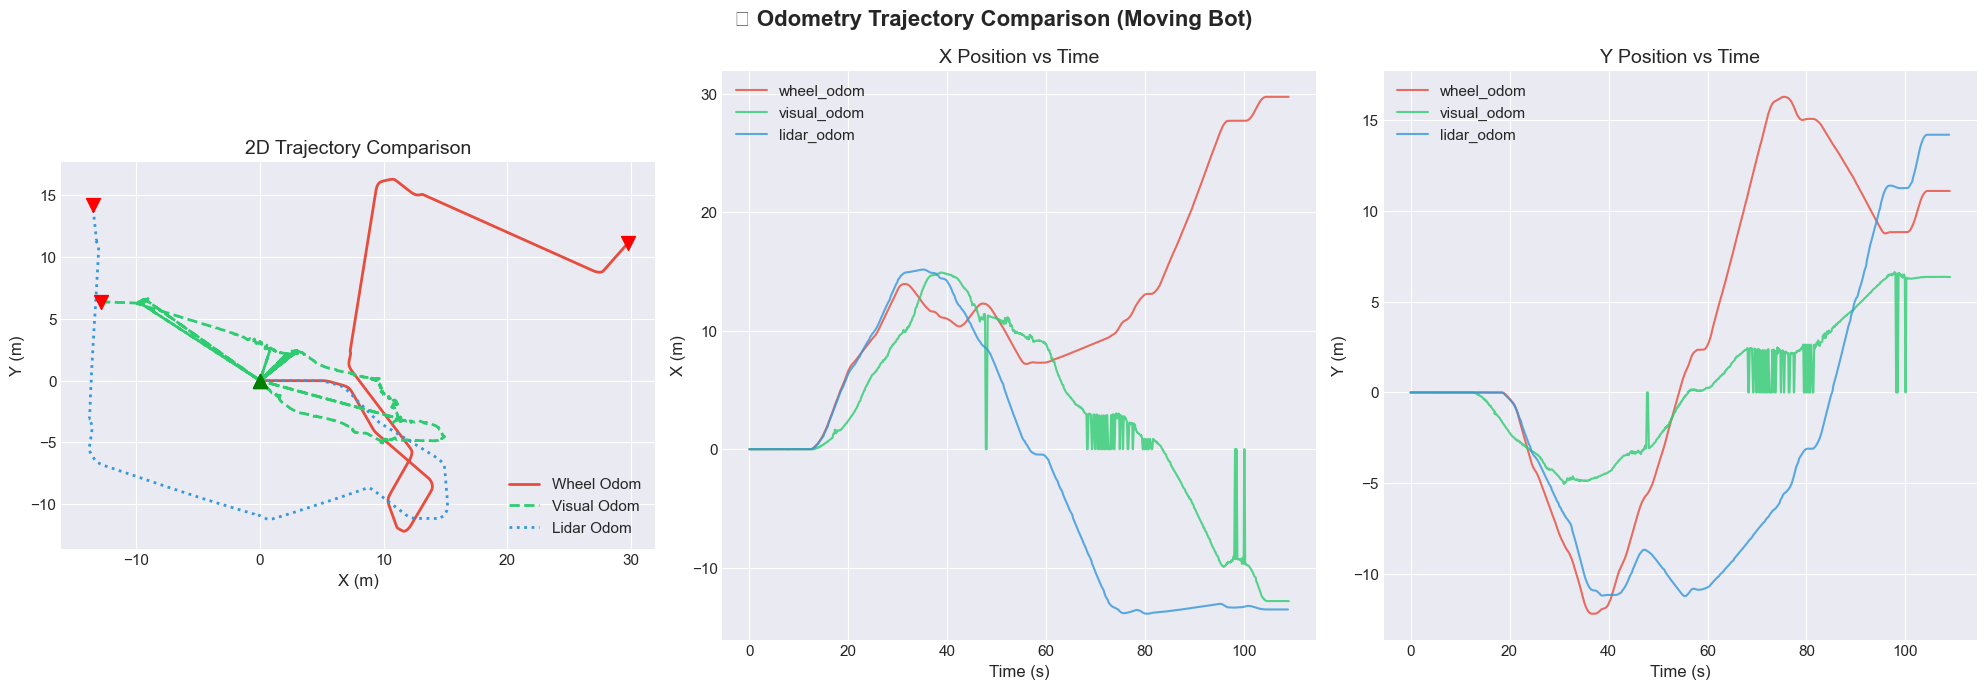


📋 Closure Error (start vs end position):
  wheel_odom: Δx=29.7596m, Δy=11.1071m, total=31.7647m
  visual_odom: Δx=-12.8314m, Δy=6.3590m, total=14.3207m
  lidar_odom: Δx=-13.5335m, Δy=14.2058m, total=19.6204m


In [2]:
fig, axes = plt.subplots(1, 3, figsize=(20, 7))

ax = axes[0]
for name, color, ls in [('wheel_odom', '#e74c3c', '-'), ('visual_odom', '#2ecc71', '--'), ('lidar_odom', '#3498db', ':')]:
    if name in dfs:
        df = dfs[name]
        ax.plot(df['x'].values, df['y'].values, ls, color=color, label=name.replace('_', ' ').title(), linewidth=2)
        ax.scatter(df['x'].iloc[0], df['y'].iloc[0], c='green', s=100, zorder=5, marker='^')
        ax.scatter(df['x'].iloc[-1], df['y'].iloc[-1], c='red', s=100, zorder=5, marker='v')
ax.set_xlabel('X (m)'); ax.set_ylabel('Y (m)')
ax.set_title('2D Trajectory Comparison'); ax.legend(); ax.set_aspect('equal'); ax.grid(True)

for idx, dim in enumerate(['x', 'y']):
    ax = axes[idx + 1]
    for name, color in [('wheel_odom', '#e74c3c'), ('visual_odom', '#2ecc71'), ('lidar_odom', '#3498db')]:
        if name in dfs:
            ax.plot(dfs[name]['time'].values, dfs[name][dim].values, color=color, label=name, alpha=0.8)
    ax.set_xlabel('Time (s)'); ax.set_ylabel(f'{dim.upper()} (m)')
    ax.set_title(f'{dim.upper()} Position vs Time'); ax.legend()

plt.suptitle('📊 Odometry Trajectory Comparison (Moving Bot)', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

print("\n📋 Closure Error (start vs end position):")
for name in ['wheel_odom', 'visual_odom', 'lidar_odom']:
    if name in dfs:
        df = dfs[name]
        dx = df['x'].iloc[-1] - df['x'].iloc[0]
        dy = df['y'].iloc[-1] - df['y'].iloc[0]
        print(f"  {name}: Δx={dx:.4f}m, Δy={dy:.4f}m, total={np.sqrt(dx**2+dy**2):.4f}m")


### 2.1 GPS Trajectory

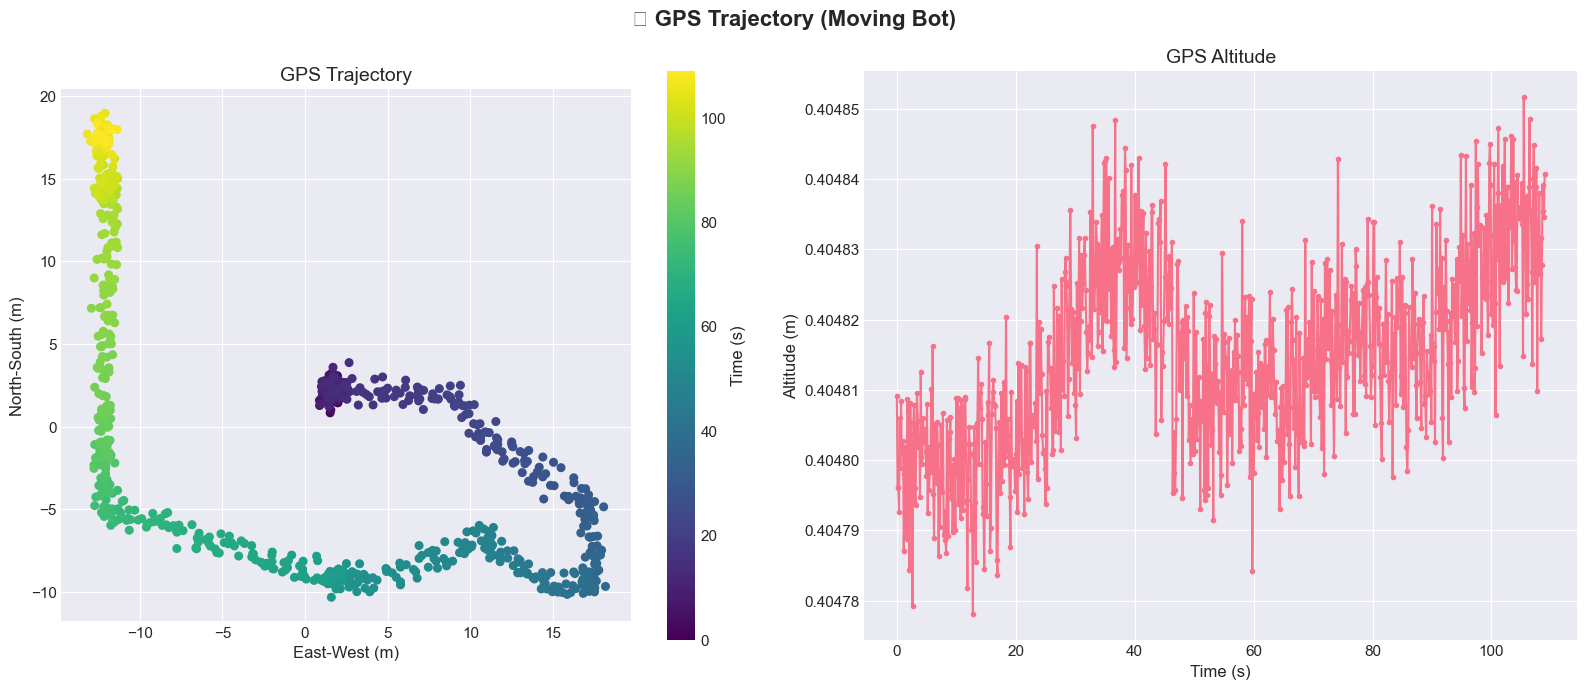

In [3]:
if 'gps' in dfs:
    gps = dfs['gps']
    lat_m = (gps['lat'] - gps['lat'].mean()) * 111320
    lon_m = (gps['lon'] - gps['lon'].mean()) * 111320 * np.cos(np.radians(gps['lat'].mean()))

    fig, axes = plt.subplots(1, 2, figsize=(16, 7))
    sc = axes[0].scatter(lon_m.values, lat_m.values, c=gps['time'].values, cmap='viridis', s=30)
    axes[0].set_xlabel('East-West (m)'); axes[0].set_ylabel('North-South (m)')
    axes[0].set_title('GPS Trajectory'); axes[0].set_aspect('equal')
    plt.colorbar(sc, ax=axes[0], label='Time (s)')

    axes[1].plot(gps['time'].values, gps['alt'].values, 'o-', markersize=3)
    axes[1].set_xlabel('Time (s)'); axes[1].set_ylabel('Altitude (m)')
    axes[1].set_title('GPS Altitude')

    plt.suptitle('📊 GPS Trajectory (Moving Bot)', fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.show()


## 3. IMU During Motion

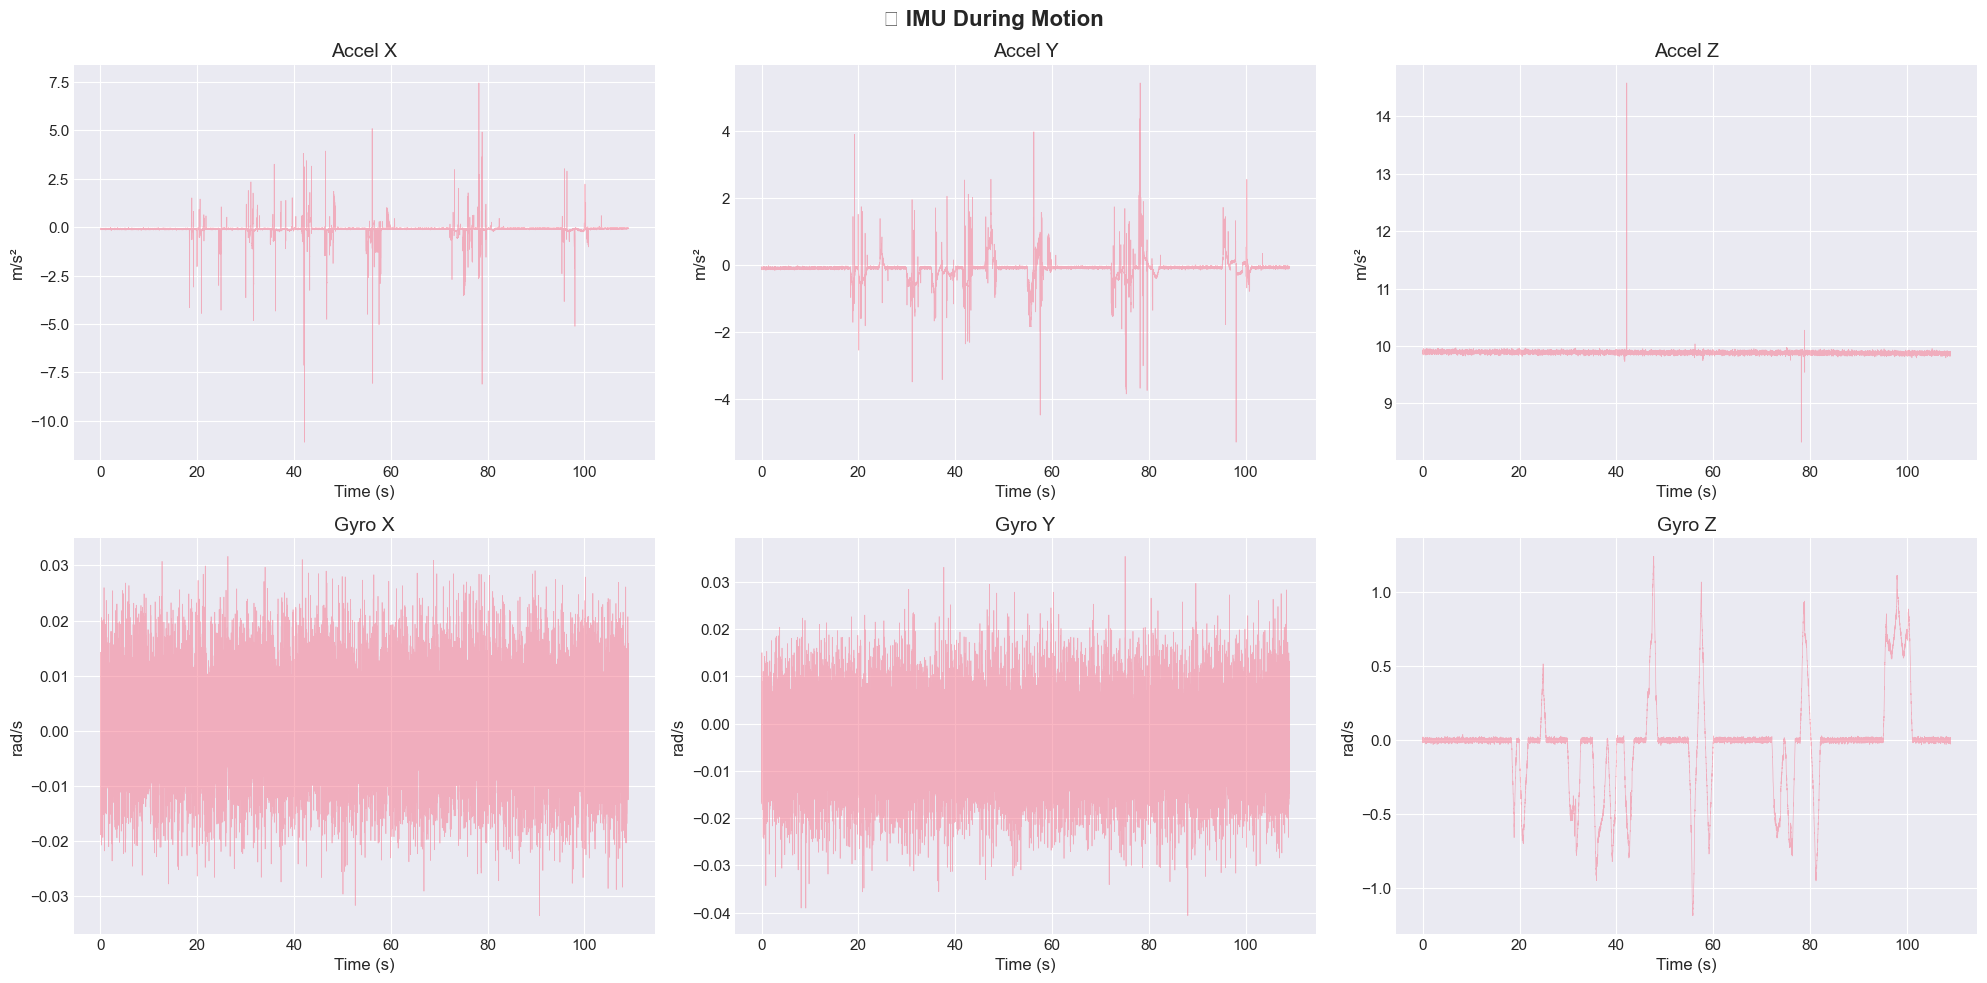

In [4]:
imu = dfs['imu']
fig, axes = plt.subplots(2, 3, figsize=(20, 10))
for i, (col, label) in enumerate([('ax','Accel X'), ('ay','Accel Y'), ('az','Accel Z')]):
    axes[0,i].plot(imu['time'].values, imu[col].values, alpha=0.5, linewidth=0.5)
    axes[0,i].set_title(label); axes[0,i].set_ylabel('m/s²')
for i, (col, label) in enumerate([('gx','Gyro X'), ('gy','Gyro Y'), ('gz','Gyro Z')]):
    axes[1,i].plot(imu['time'].values, imu[col].values, alpha=0.5, linewidth=0.5)
    axes[1,i].set_title(label); axes[1,i].set_ylabel('rad/s')
for ax in axes.flat: ax.set_xlabel('Time (s)')
plt.suptitle('📊 IMU During Motion', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()


## 4. Velocity Profiles

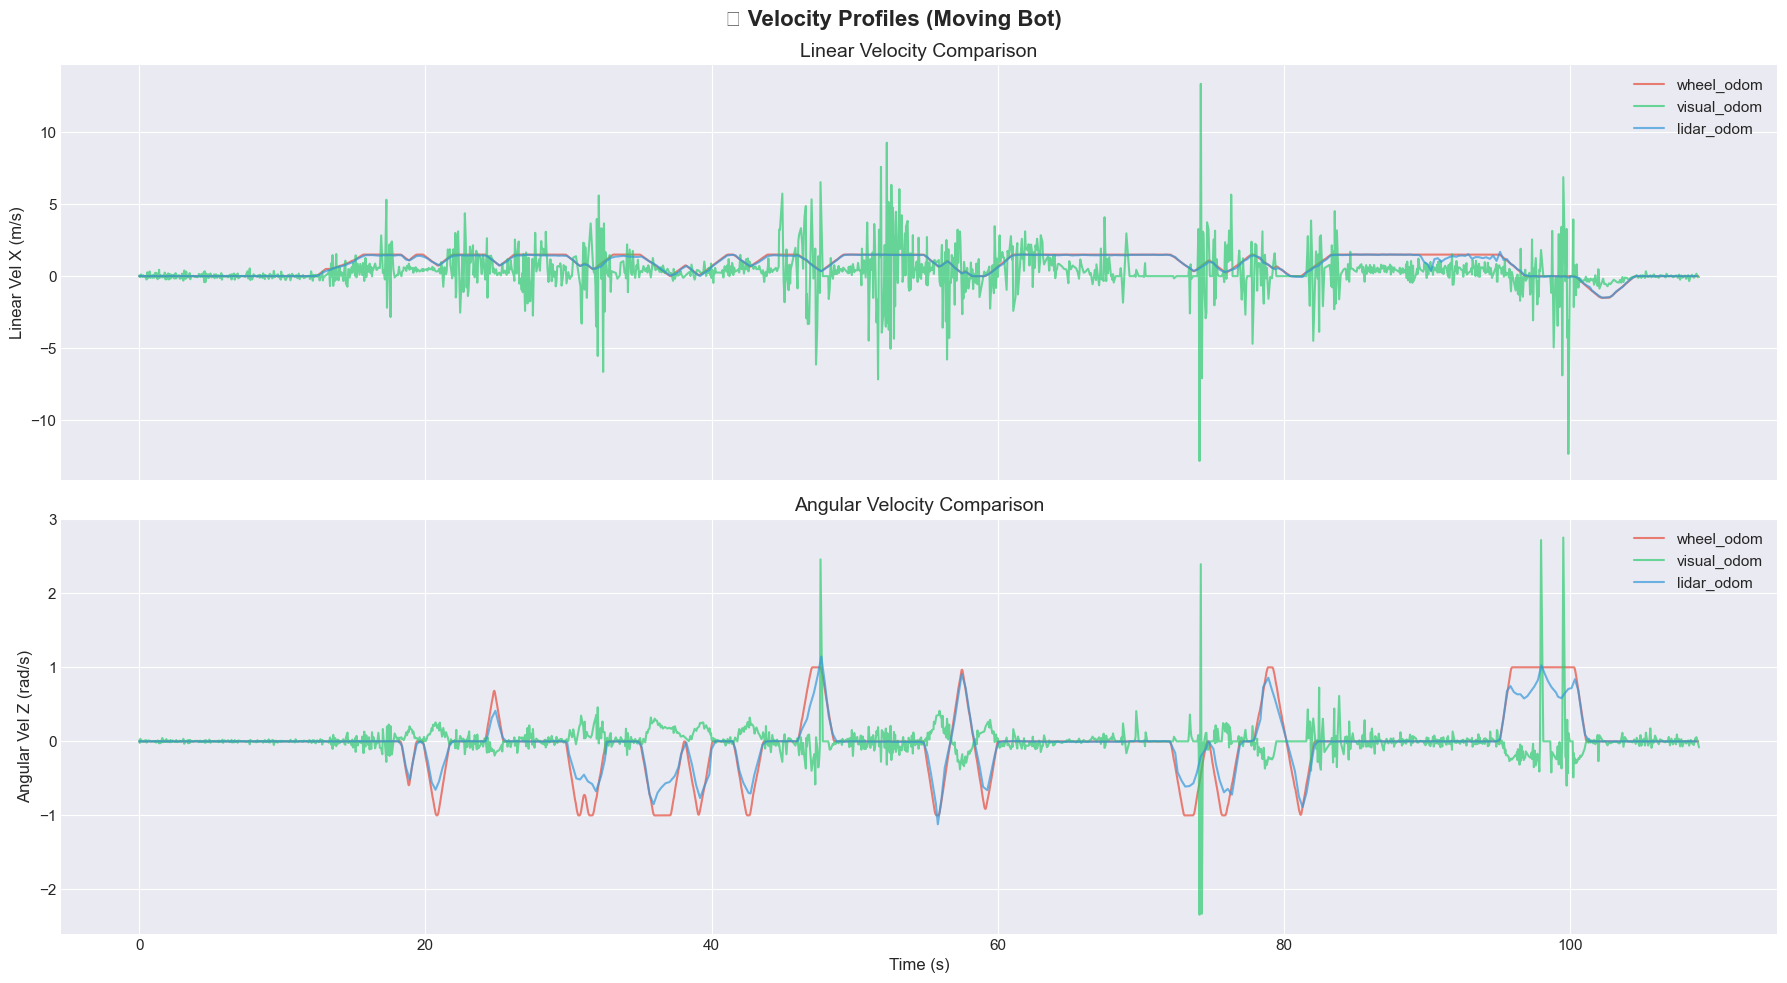

In [5]:
fig, axes = plt.subplots(2, 1, figsize=(18, 10), sharex=True)
for name, color in [('wheel_odom', '#e74c3c'), ('visual_odom', '#2ecc71'), ('lidar_odom', '#3498db')]:
    if name in dfs:
        axes[0].plot(dfs[name]['time'].values, dfs[name]['vx'].values, color=color, label=name, alpha=0.7)
        axes[1].plot(dfs[name]['time'].values, dfs[name]['wz'].values, color=color, label=name, alpha=0.7)
axes[0].set_ylabel('Linear Vel X (m/s)'); axes[0].set_title('Linear Velocity Comparison'); axes[0].legend()
axes[1].set_ylabel('Angular Vel Z (rad/s)'); axes[1].set_title('Angular Velocity Comparison')
axes[1].legend(); axes[1].set_xlabel('Time (s)')
plt.suptitle('📊 Velocity Profiles (Moving Bot)', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()


## 5. Noise Distribution (Detrended)
During motion, we detrend the signal first to isolate noise from actual motion.

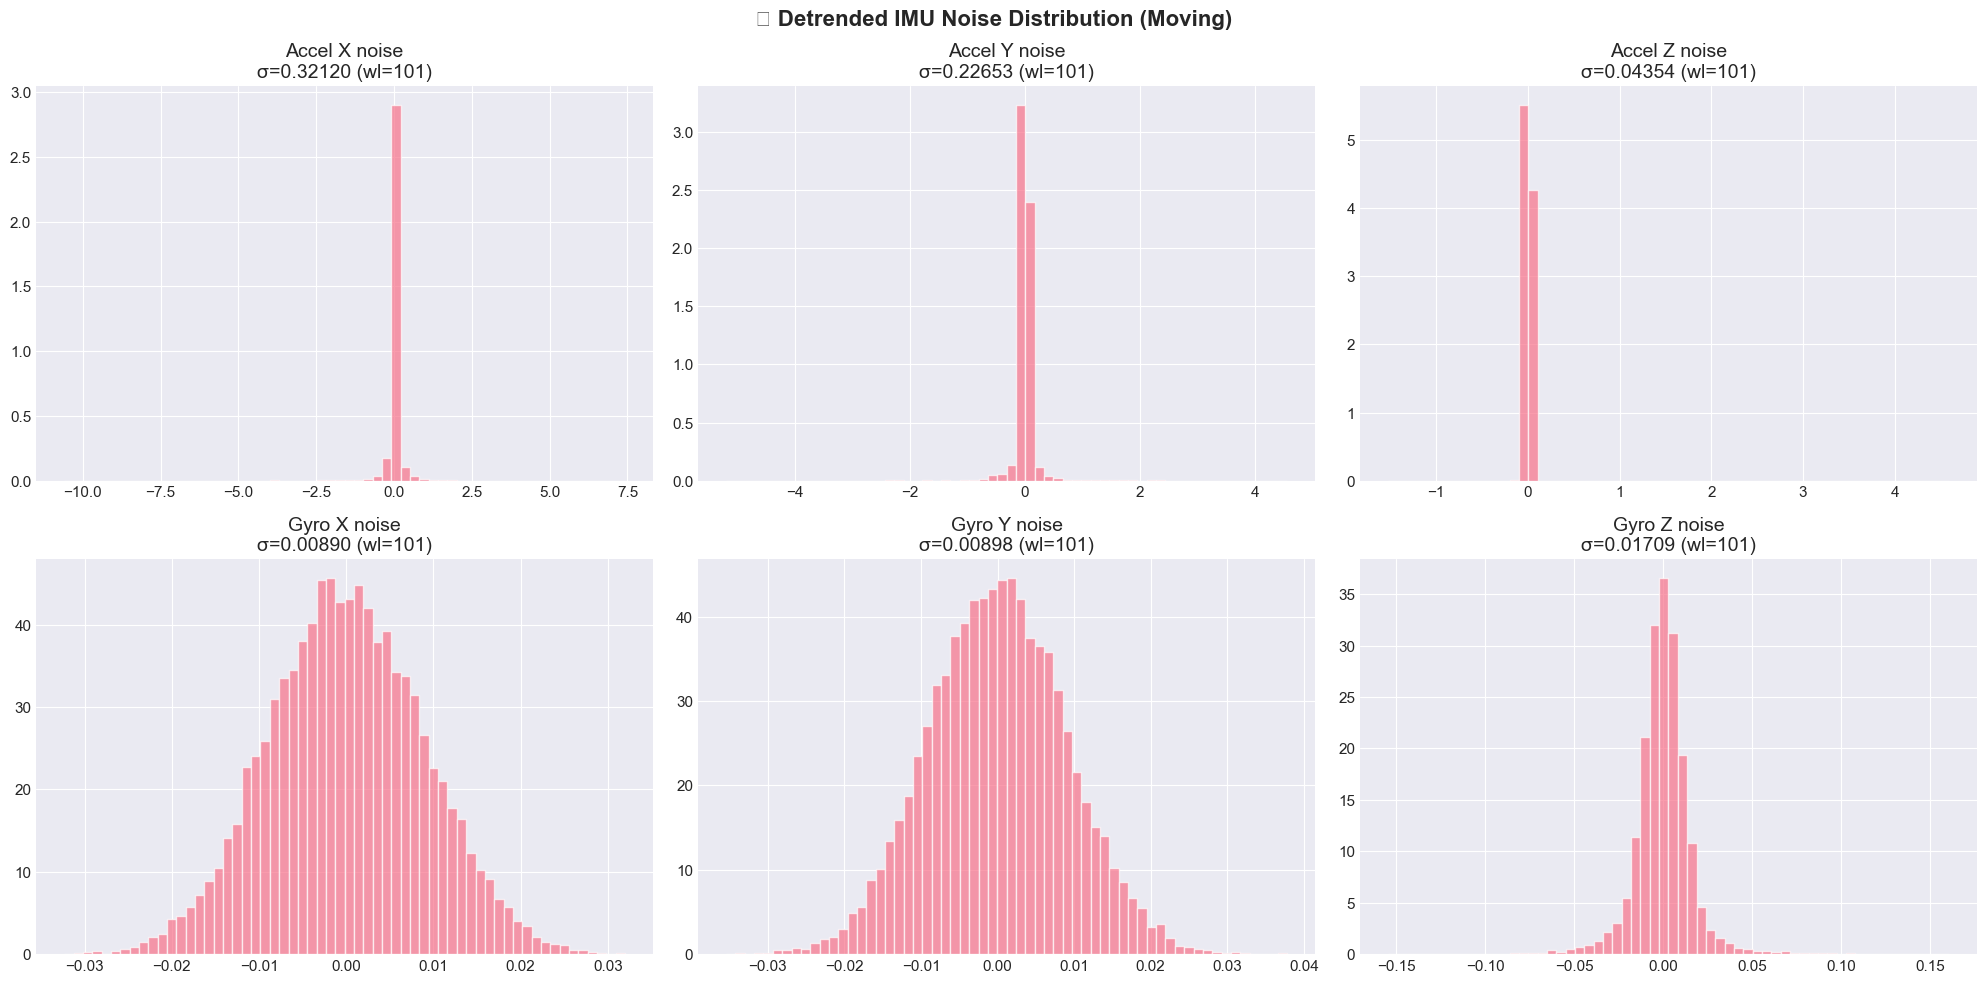

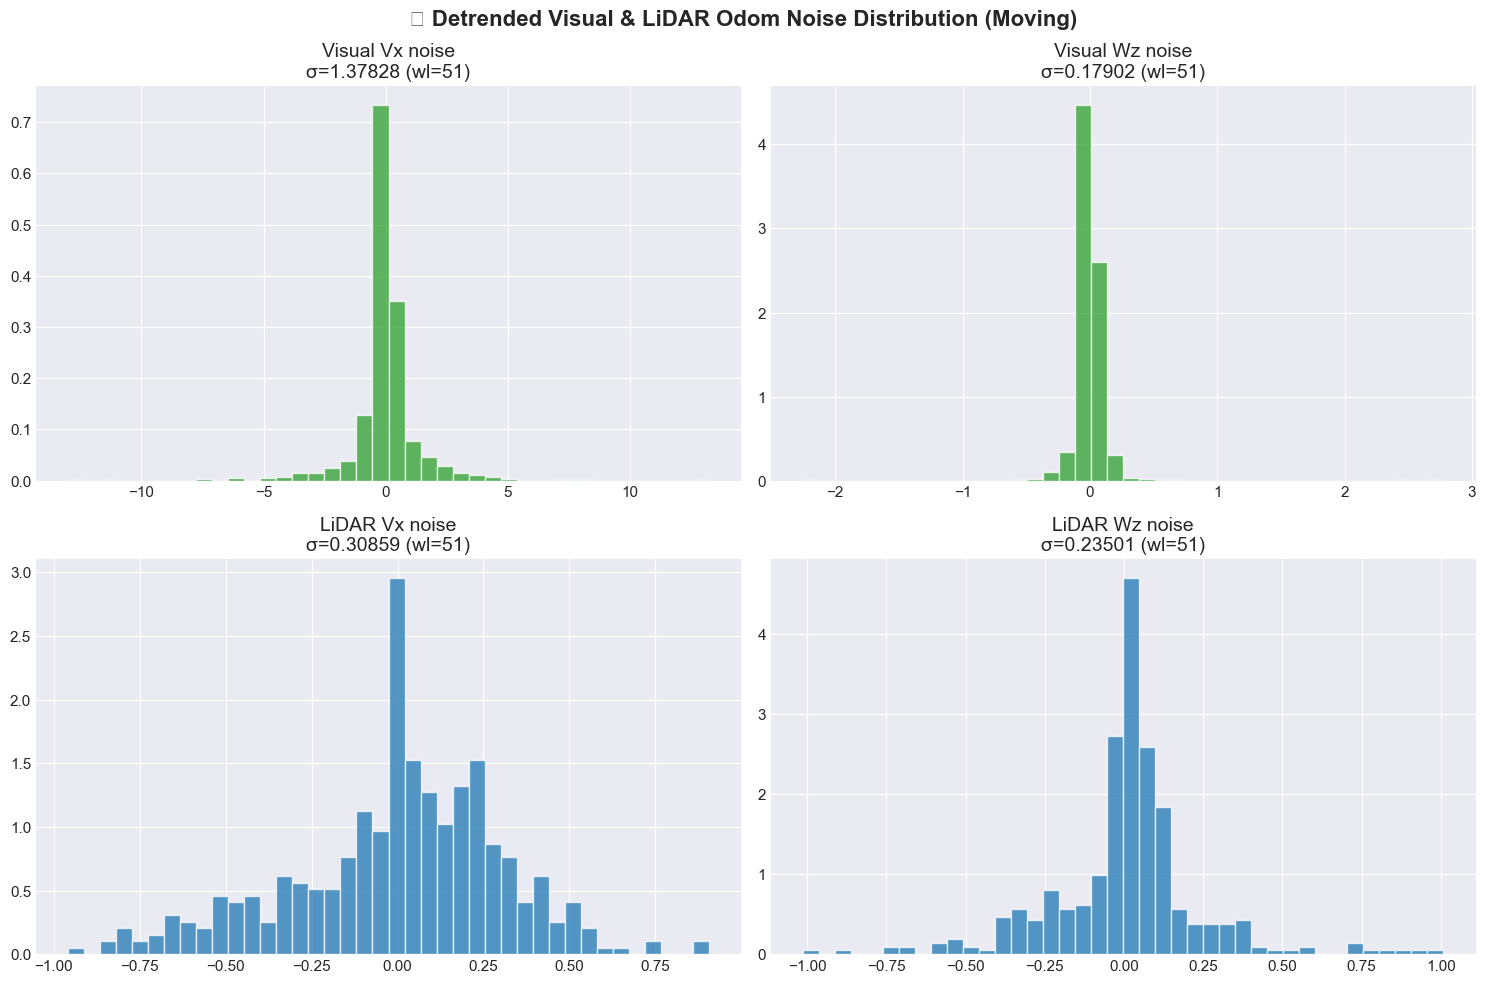

In [12]:
imu = dfs['imu']
fig, axes = plt.subplots(2, 3, figsize=(20, 10))

# IMU detrended noise
for i, (col, label) in enumerate([('ax','Accel X'), ('ay','Accel Y'), ('az','Accel Z')]):
    wl = min(101, max(5, len(imu)//100*2+1))
    if wl % 2 == 0: wl += 1
    trend = savgol_filter(imu[col].values, wl, 3)
    noise = imu[col].values - trend
    axes[0, i].hist(noise, bins=60, density=True, alpha=0.7, edgecolor='white')
    axes[0, i].set_title(f'{label} noise\nσ={np.std(noise):.5f} (wl={wl})')

for i, (col, label) in enumerate([('gx','Gyro X'), ('gy','Gyro Y'), ('gz','Gyro Z')]):
    wl = min(101, max(5, len(imu)//100*2+1))
    if wl % 2 == 0: wl += 1
    trend = savgol_filter(imu[col].values, wl, 3)
    noise = imu[col].values - trend
    axes[1, i].hist(noise, bins=60, density=True, alpha=0.7, edgecolor='white')
    axes[1, i].set_title(f'{label} noise\nσ={np.std(noise):.5f} (wl={wl})')

plt.suptitle('📊 Detrended IMU Noise Distribution (Moving)', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

# Visual and LiDAR odometry detrended noise (includes Visual explicitly)
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
odom_sources = [('visual_odom', 'Visual', 'tab:green'), ('lidar_odom', 'LiDAR', 'tab:blue')]

for i, (key, name, color) in enumerate(odom_sources):
    if key not in dfs or len(dfs[key]) < 7:
        for j in range(2):
            axes[i, j].text(0.5, 0.5, f'{name} data not available', ha='center', va='center')
            axes[i, j].set_axis_off()
        continue

    df = dfs[key]
    for j, (col, label) in enumerate([('vx', 'Vx'), ('wz', 'Wz')]):
        wl = min(51, len(df)//5*2+1)
        if wl % 2 == 0:
            wl += 1
        if wl < 5:
            wl = 5
        trend = savgol_filter(df[col].values, wl, 3)
        noise = df[col].values - trend
        axes[i, j].hist(noise, bins=40, density=True, alpha=0.75, edgecolor='white', color=color)
        axes[i, j].set_title(f'{name} {label} noise\nσ={np.std(noise):.5f} (wl={wl})')

plt.suptitle('📊 Detrended Visual & LiDAR Odom Noise Distribution (Moving)', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

## 6. Filtering During Motion

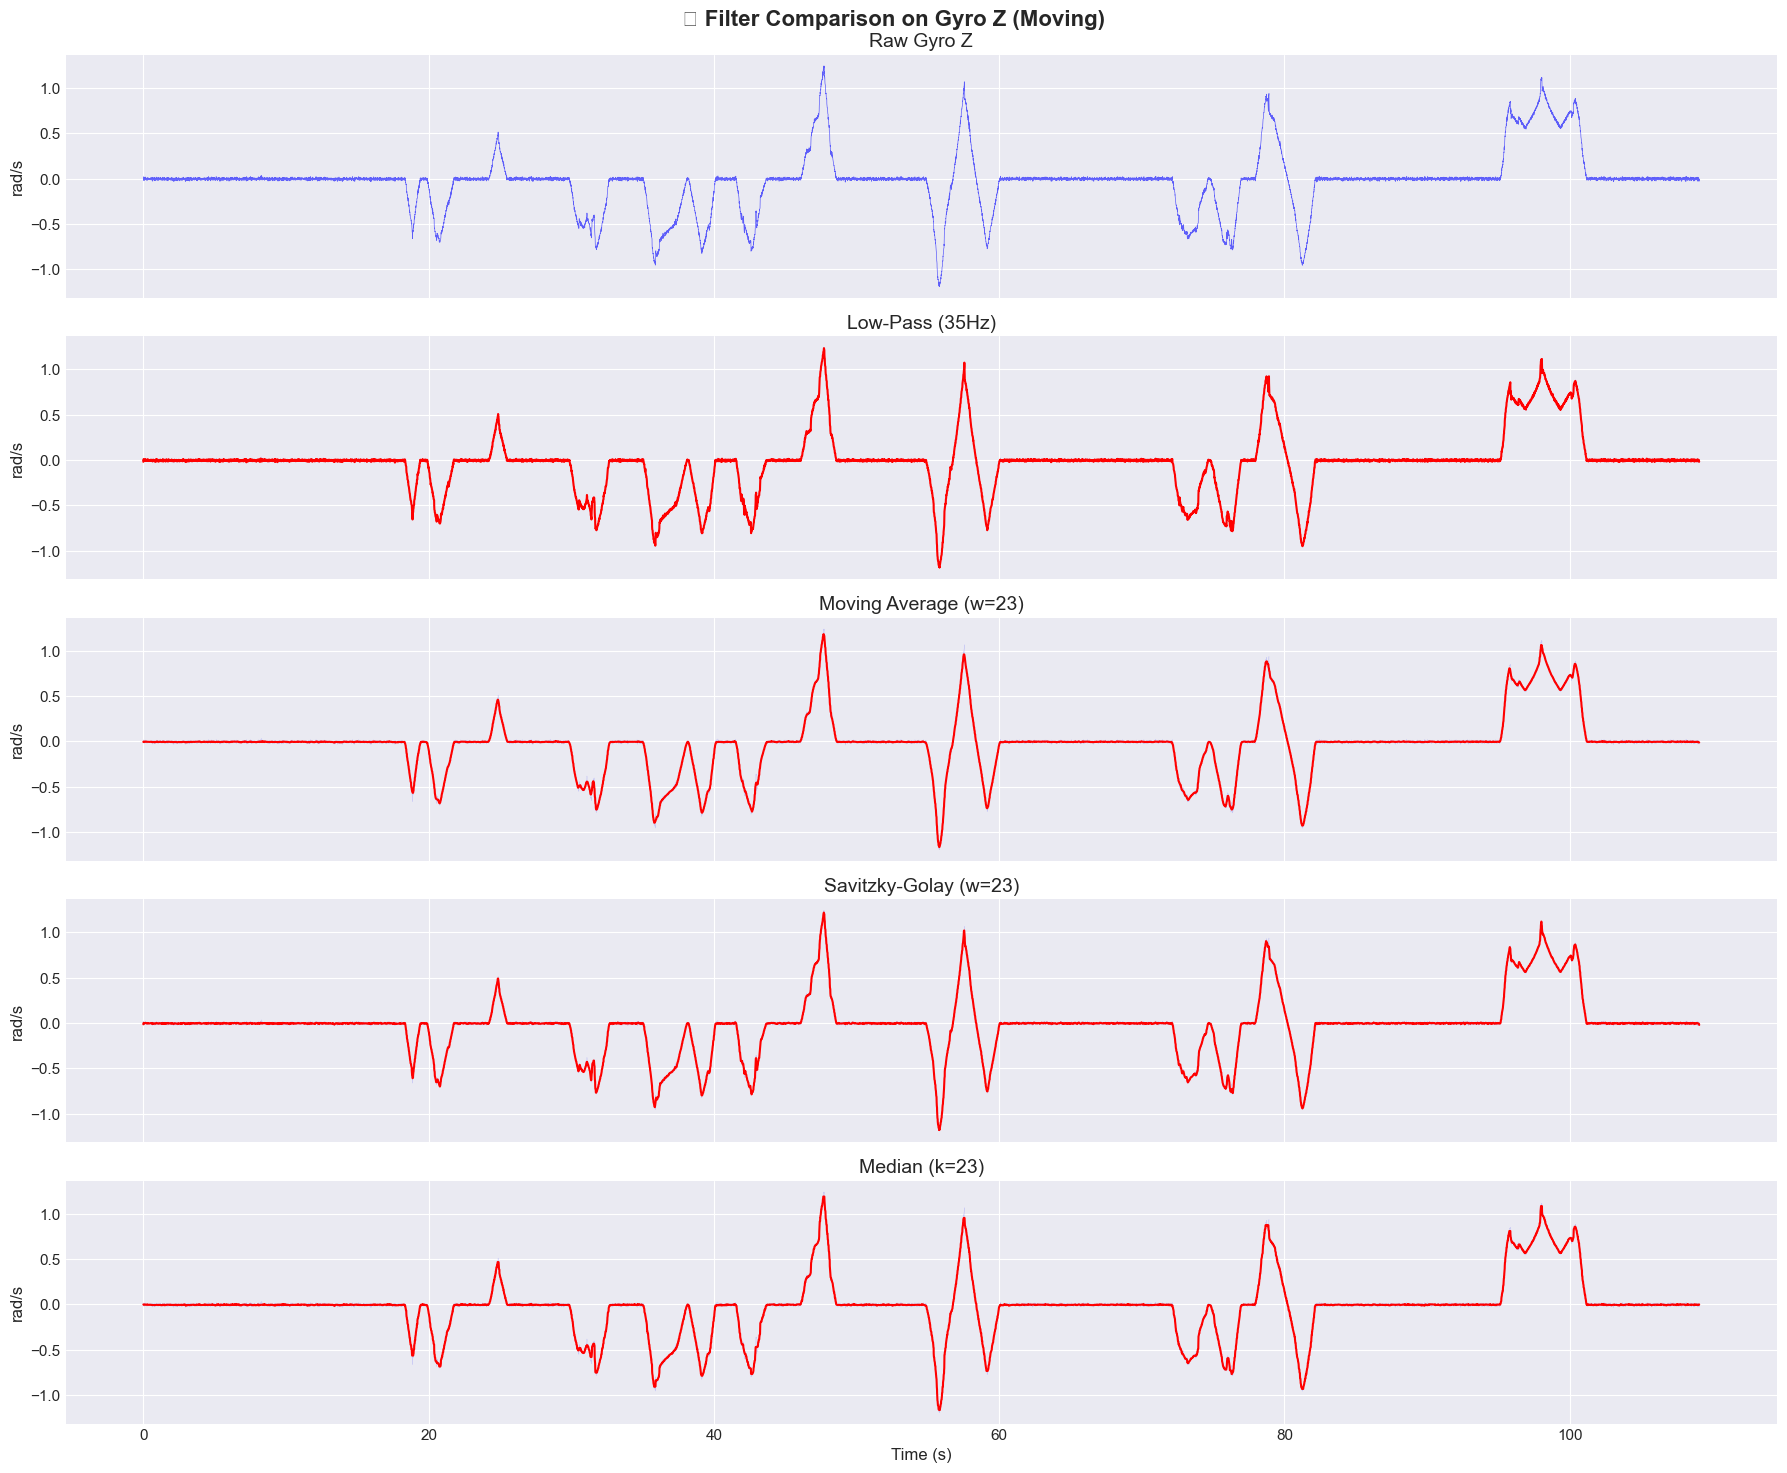

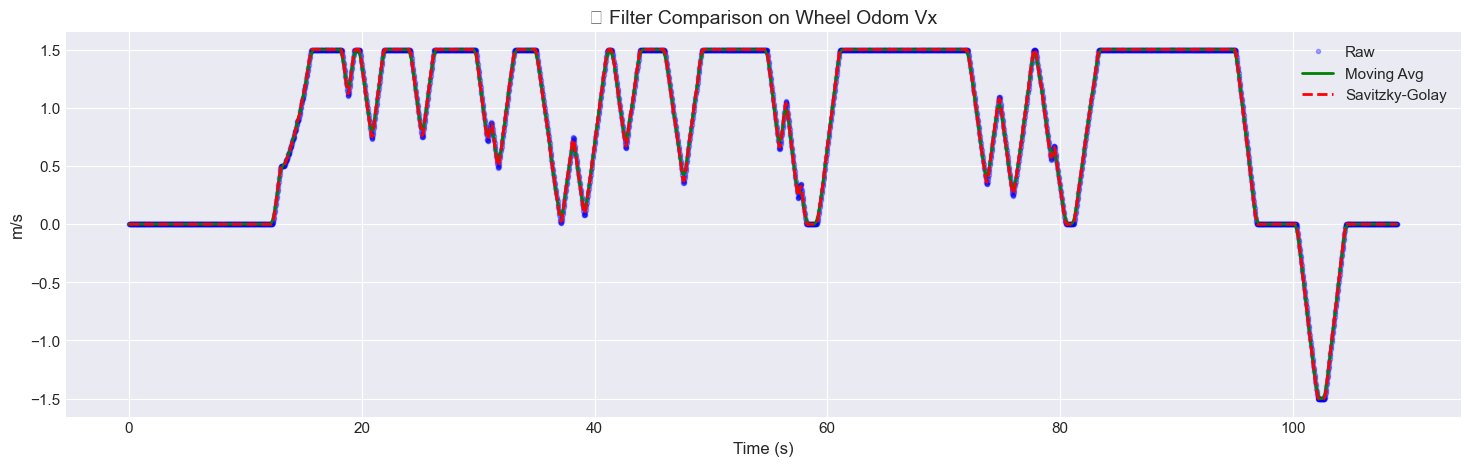

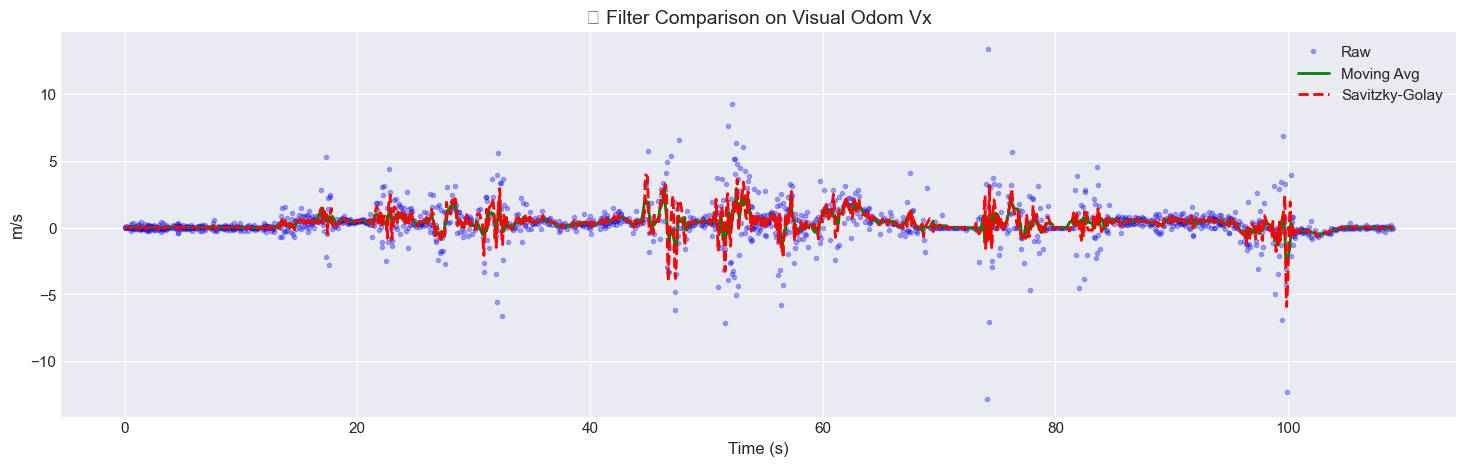

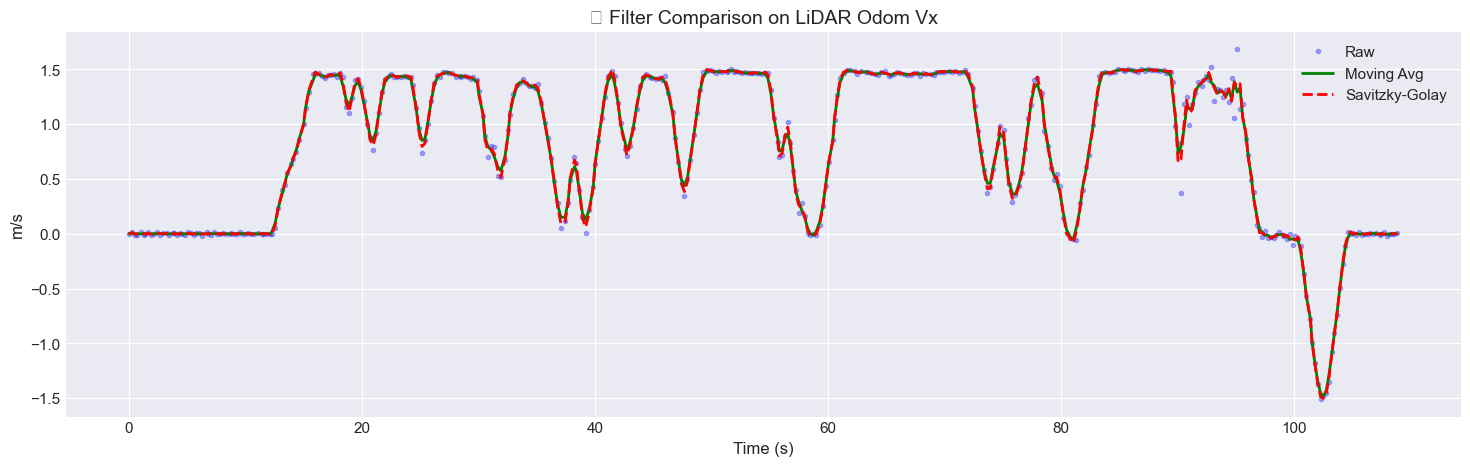

In [7]:
raw_gz = imu['gz'].values.copy()
t = imu['time'].values.copy()

filtered = {}
# Use Nyquist-aware cutoff: 35 Hz for ~154 Hz IMU (preserves vehicle dynamics)
cutoff_hz = min(35.0, fs_imu * 0.45)  # Stay well below Nyquist
b, a = butter(4, cutoff_hz/(fs_imu/2), btype='low')
filtered[f'Low-Pass ({cutoff_hz:.0f}Hz)'] = filtfilt(b, a, raw_gz)
# Scale window to ~0.5s of sampling rate instead of fixed 21 samples
ma_window = max(3, int(fs_imu * 0.15) | 1)  # ~0.15s window, ensure odd
filtered[f'Moving Average (w={ma_window})'] = uniform_filter1d(raw_gz, size=ma_window)
# Scale Savitzky-Golay window to ~0.15s of sampling rate
sg_window = max(5, int(fs_imu * 0.15) | 1)  # ~0.15s window, ensure odd
filtered[f'Savitzky-Golay (w={sg_window})'] = savgol_filter(raw_gz, sg_window, 3)
# Scale Median filter window to ~0.15s of sampling rate
med_window = max(3, int(fs_imu * 0.15) | 1)  # ~0.15s window, ensure odd
filtered[f'Median (k={med_window})'] = medfilt(raw_gz, kernel_size=med_window)

fig, axes = plt.subplots(len(filtered)+1, 1, figsize=(18, 3*(len(filtered)+1)), sharex=True)
axes[0].plot(t, raw_gz, 'b-', alpha=0.6, linewidth=0.5)
axes[0].set_title('Raw Gyro Z'); axes[0].set_ylabel('rad/s')
for i, (name, filt) in enumerate(filtered.items()):
    axes[i+1].plot(t, raw_gz, 'b-', alpha=0.15, linewidth=0.3)
    axes[i+1].plot(t, filt, 'r-', linewidth=1.5)
    axes[i+1].set_title(name); axes[i+1].set_ylabel('rad/s')
axes[-1].set_xlabel('Time (s)')
plt.suptitle('📊 Filter Comparison on Gyro Z (Moving)', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

# Filtering on Odometry sources
for key, label in [('wheel_odom', 'Wheel'), ('visual_odom', 'Visual'), ('lidar_odom', 'LiDAR')]:
    if key in dfs:
        df = dfs[key]
        raw_vx = df['vx'].values
        t_odom = df['time'].values
        
        # Scale odometry MA window to ~0.5s of actual sampling rate
        fs_odom = 1.0 / np.mean(np.diff(df['time'].values)) if len(df) > 1 else 50.0
        odom_ma_w = max(3, int(fs_odom * 0.5) | 1)
        f_ma = uniform_filter1d(raw_vx, size=odom_ma_w)
        odom_sg_w = max(5, int(fs_odom * 0.5) | 1)
        f_sg = savgol_filter(raw_vx, odom_sg_w, 3)
        
        plt.figure(figsize=(18, 5))
        plt.plot(t_odom, raw_vx, 'b.', alpha=0.3, label='Raw')
        plt.plot(t_odom, f_ma, 'g-', linewidth=2, label='Moving Avg')
        plt.plot(t_odom, f_sg, 'r--', linewidth=2, label='Savitzky-Golay')
        plt.title(f'📊 Filter Comparison on {label} Odom Vx')
        plt.ylabel('m/s'); plt.xlabel('Time (s)'); plt.legend(); plt.show()

## 7. Fourier Analysis & PSD (Moving)

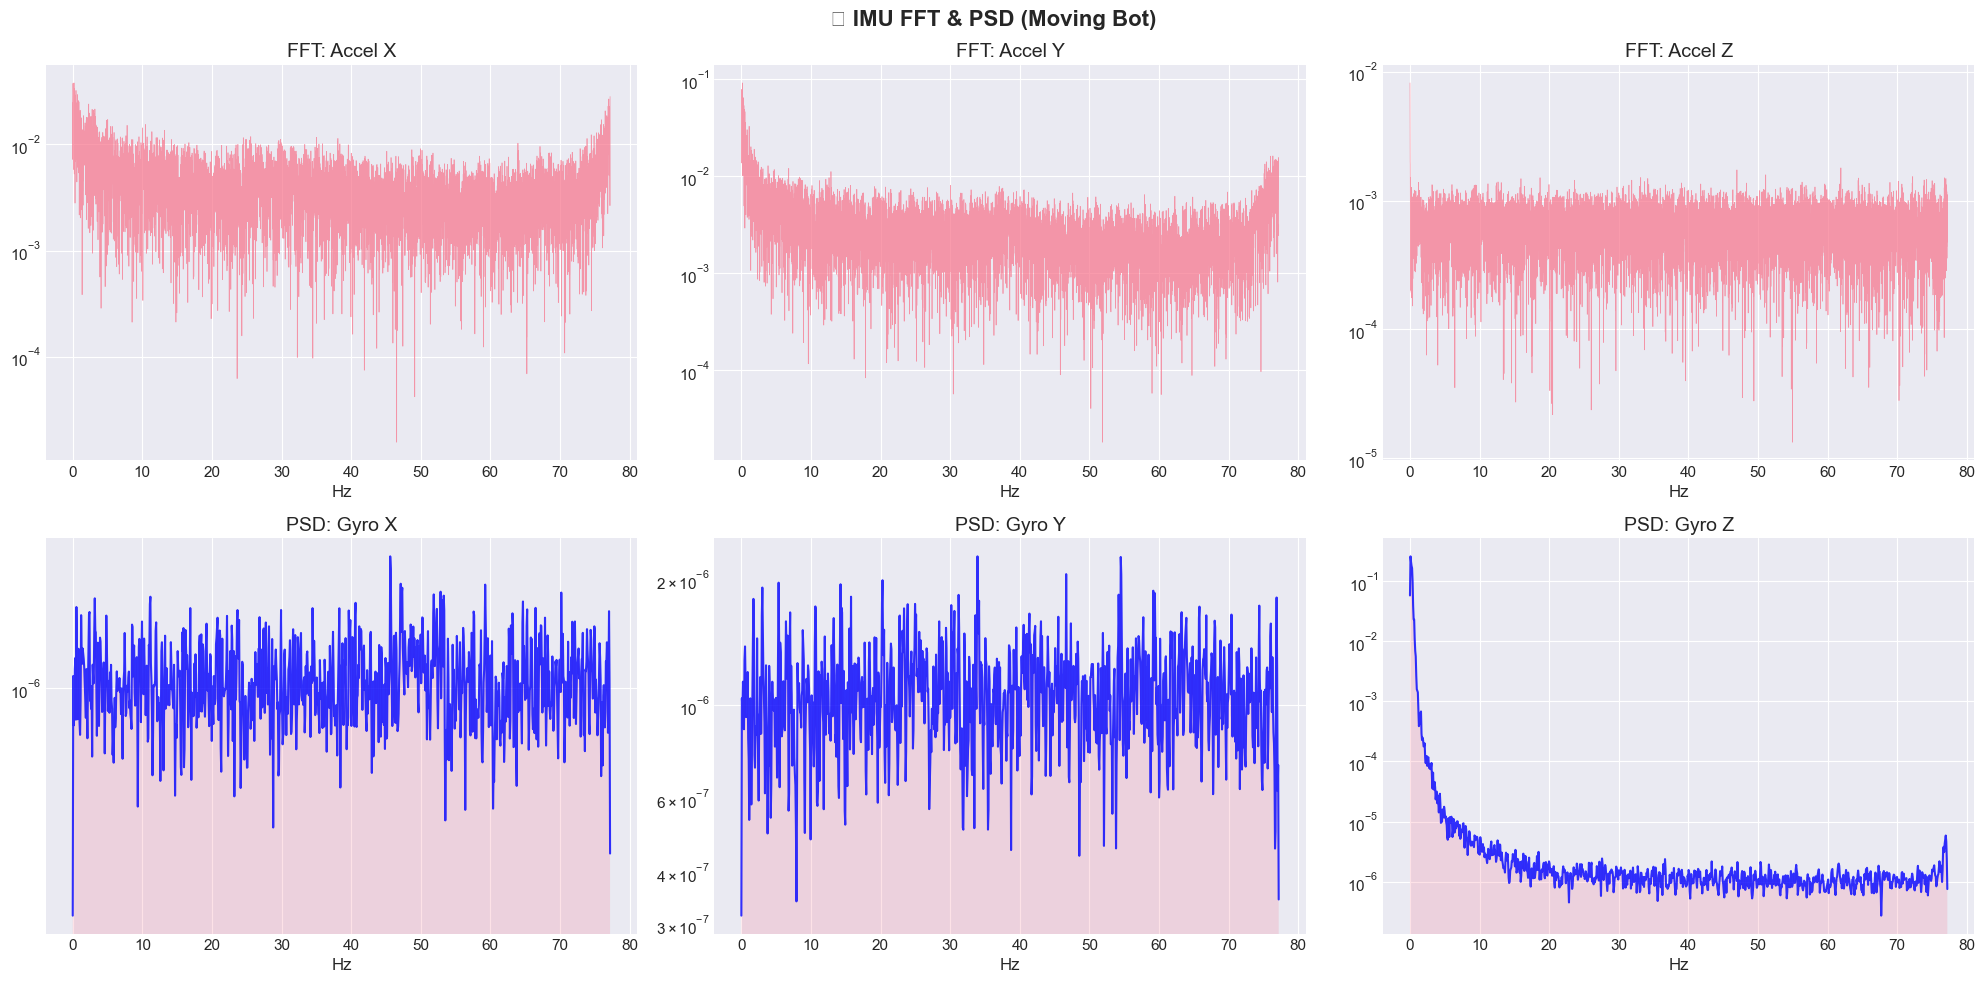

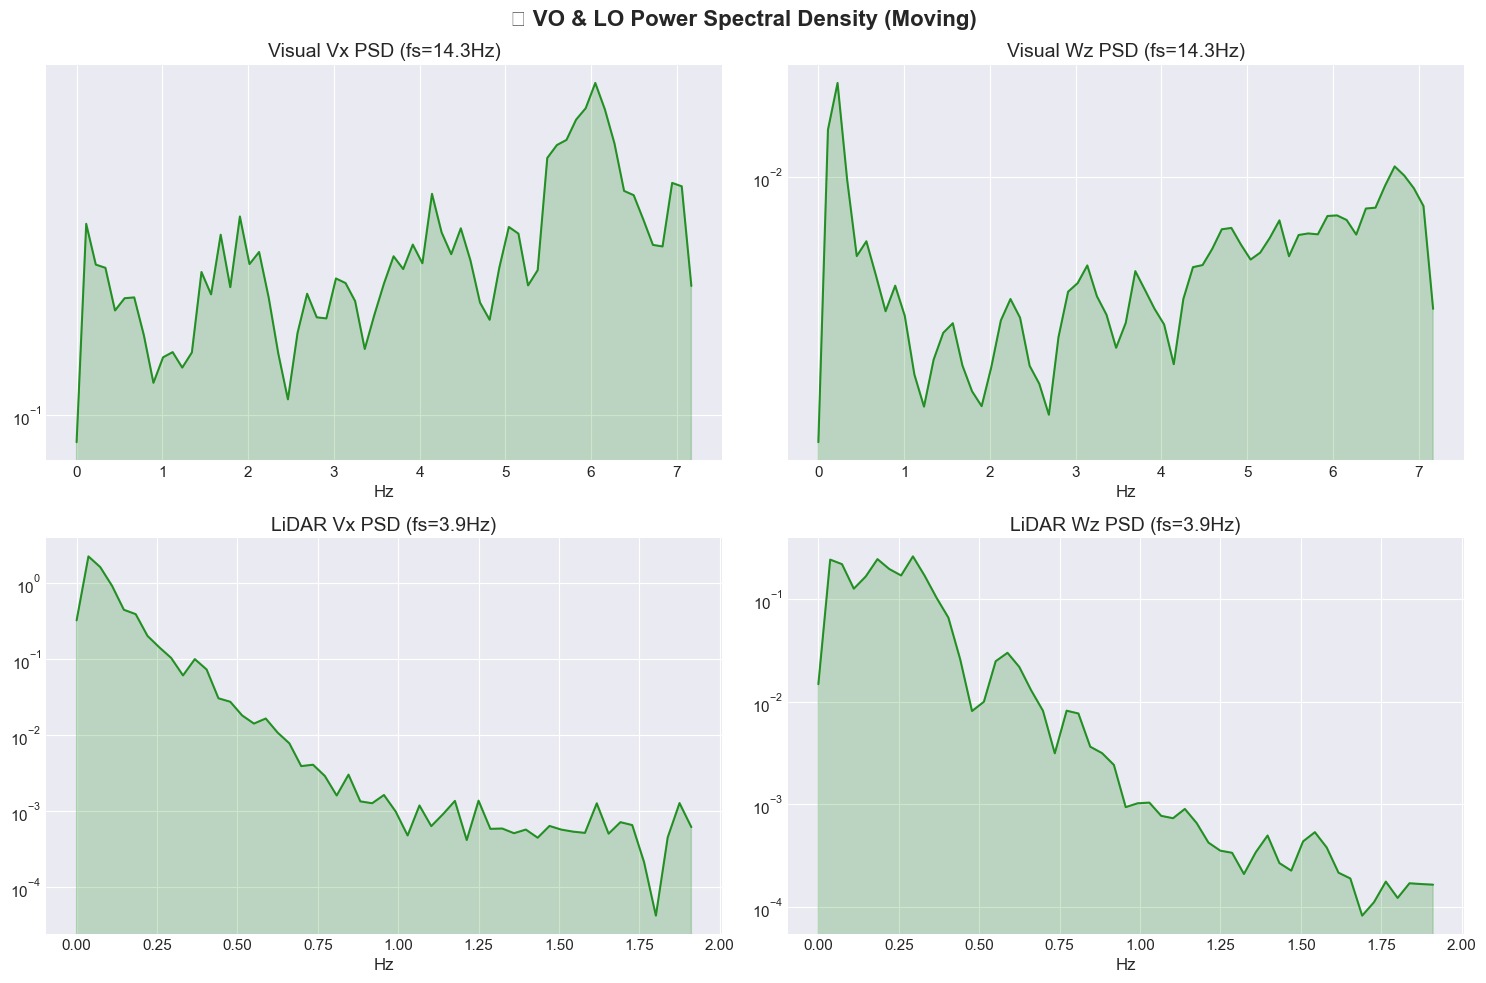

In [8]:
imu = dfs['imu']
fig, axes = plt.subplots(2, 3, figsize=(20, 10))
for i, (col, label) in enumerate([('ax','Accel X'), ('ay','Accel Y'), ('az','Accel Z')]):
    d = imu[col].values - np.mean(imu[col].values)
    freqs = rfftfreq(len(d), 1.0/fs_imu)
    mag = np.abs(rfft(d)) * 2.0 / len(d)
    axes[0,i].semilogy(freqs[1:], mag[1:], alpha=0.7, linewidth=0.5)
    axes[0,i].set_title(f'FFT: {label}'); axes[0,i].set_xlabel('Hz')

for i, (col, label) in enumerate([('gx','Gyro X'), ('gy','Gyro Y'), ('gz','Gyro Z')]):
    f, Pxx = welch(imu[col].values - np.mean(imu[col].values), fs=fs_imu, nperseg=min(2048, len(imu)//2))
    axes[1,i].semilogy(f, Pxx, 'b-', alpha=0.8)
    axes[1,i].fill_between(f, Pxx, alpha=0.2)
    axes[1,i].set_title(f'PSD: {label}'); axes[1,i].set_xlabel('Hz')

plt.suptitle('📊 IMU FFT & PSD (Moving Bot)', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

# VO and LO FFT & PSD
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
for i, (key, name) in enumerate([('visual_odom', 'Visual'), ('lidar_odom', 'LiDAR')]):
    if key in dfs:
        df = dfs[key]
        fs = 1.0 / np.mean(np.diff(df['time'].values))
        for j, (col, label) in enumerate([('vx', 'Vx'), ('wz', 'Wz')]):
            d = df[col].values - np.mean(df[col].values)
            f, Pxx = welch(d, fs=fs, nperseg=min(128, len(df)//4))
            axes[i,j].semilogy(f, Pxx, 'g-', alpha=0.8)
            axes[i,j].fill_between(f, Pxx, alpha=0.2, color='green')
            axes[i,j].set_title(f'{name} {label} PSD (fs={fs:.1f}Hz)')
            axes[i,j].set_xlabel('Hz')
plt.suptitle('📊 VO & LO Power Spectral Density (Moving)', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()


## 8. Autocorrelation (Moving)

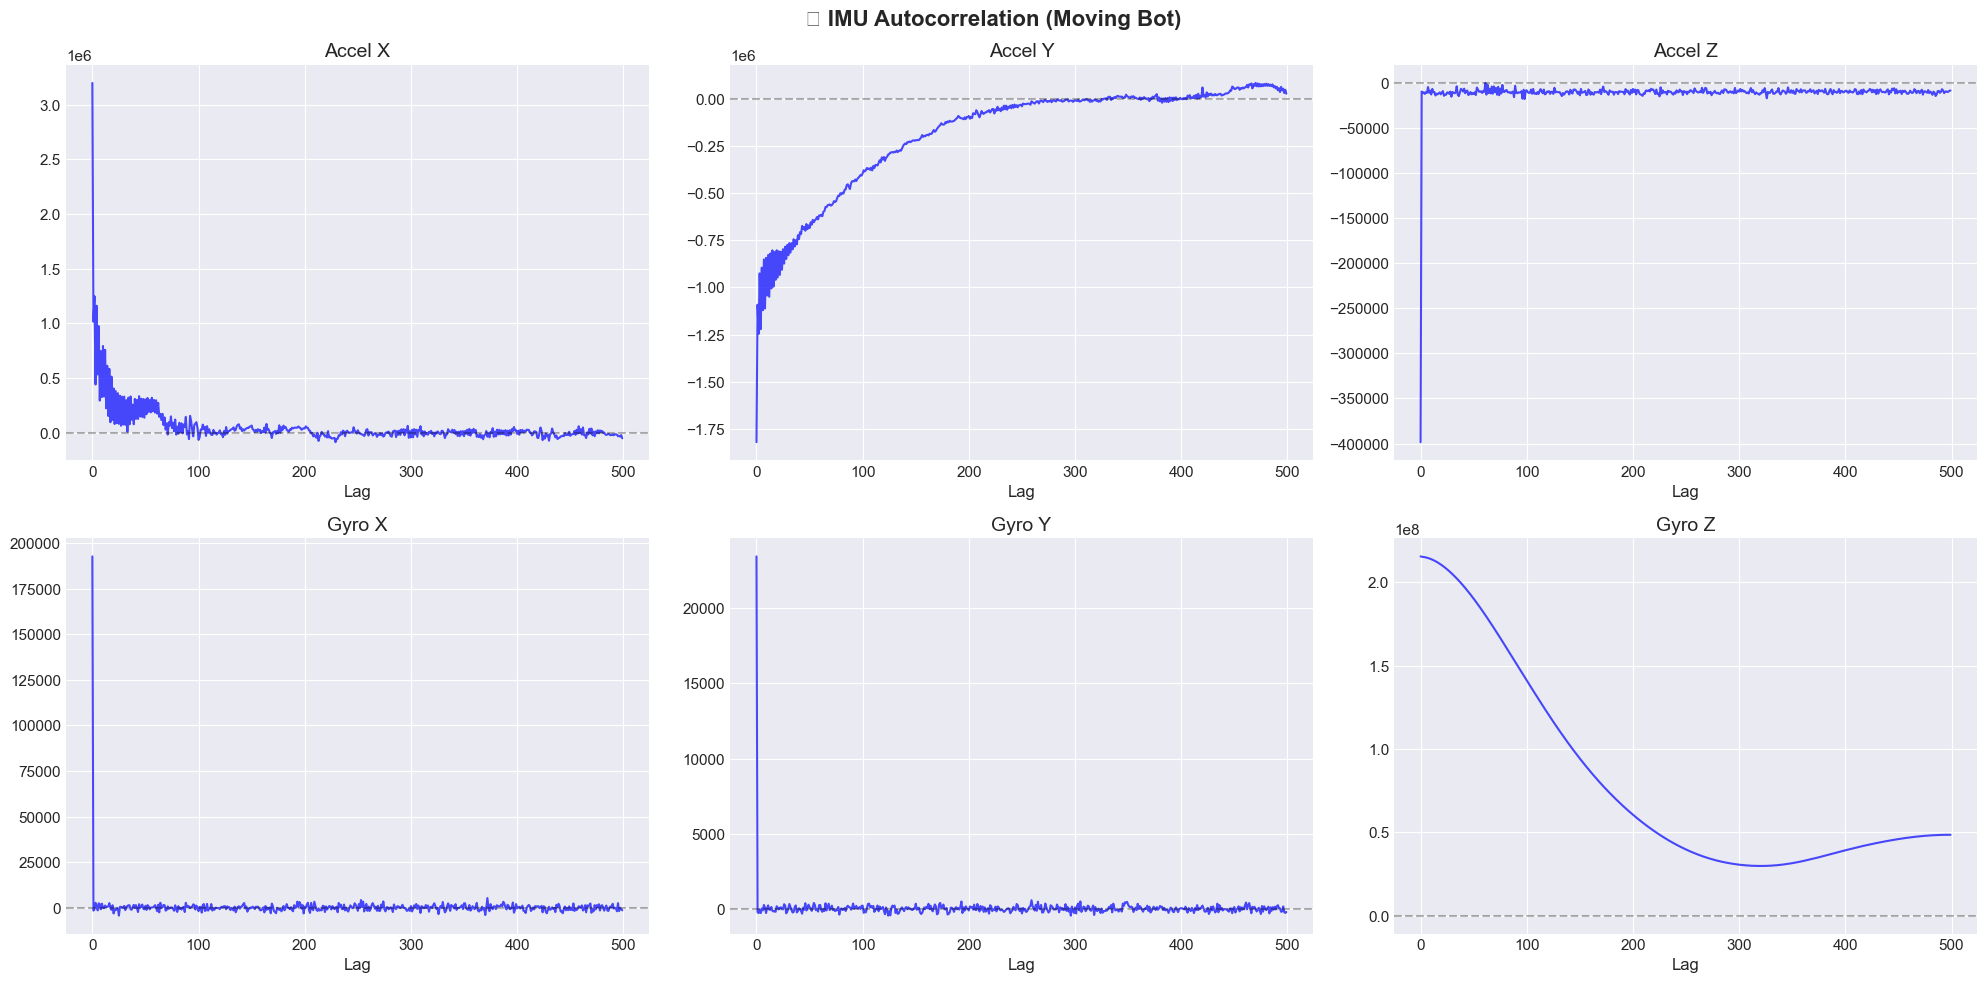

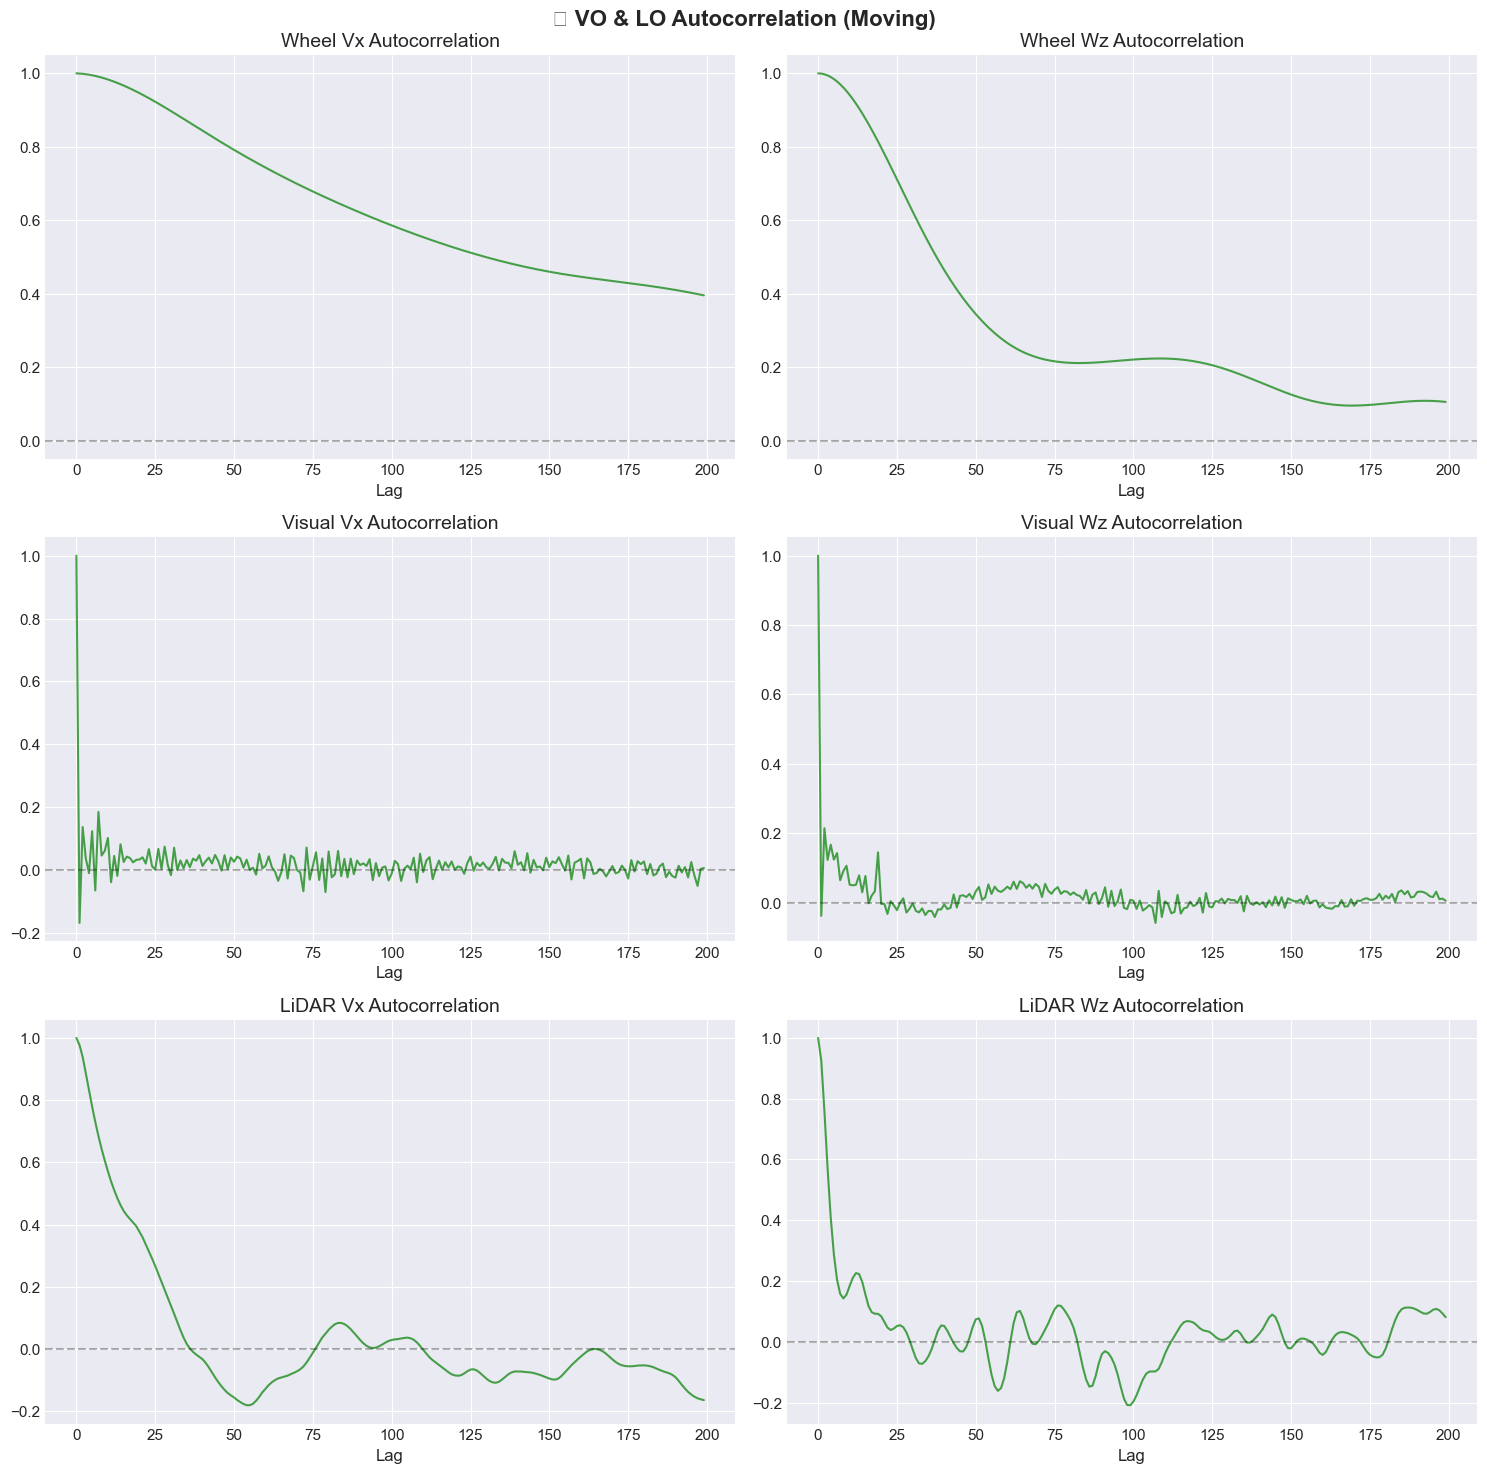

In [9]:
imu = dfs['imu']
fig, axes = plt.subplots(2, 3, figsize=(20, 10))
for idx, (col, label) in enumerate([('ax','Accel X'), ('ay','Accel Y'), ('az','Accel Z'),
                                      ('gx','Gyro X'), ('gy','Gyro Y'), ('gz','Gyro Z')]):
    row, col_i = idx // 3, idx % 3
    d = imu[col].values - np.mean(imu[col].values)
    nlags = min(500, len(d)//2)
    acf = np.correlate(d, d, mode='full')
    acf = acf[len(acf)//2:] / acf[0]
    axes[row, col_i].plot(np.arange(nlags), acf[:nlags], 'b-', alpha=0.7)
    axes[row, col_i].axhline(0, color='k', linestyle='--', alpha=0.3)
    axes[row, col_i].set_title(label); axes[row, col_i].set_xlabel('Lag')
plt.suptitle('📊 IMU Autocorrelation (Moving Bot)', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

# Autocorrelation for Odometry Sources
fig, axes = plt.subplots(3, 2, figsize=(15, 15))
for i, (key, name) in enumerate([('wheel_odom', 'Wheel'), ('visual_odom', 'Visual'), ('lidar_odom', 'LiDAR')]):
    if key in dfs:
        df = dfs[key]
        for j, (col, label) in enumerate([('vx', 'Vx'), ('wz', 'Wz')]):
            d = df[col].values - np.mean(df[col].values)
            nlags = min(200, len(d)//2)
            acf = np.correlate(d, d, mode='full')
            acf = acf[len(acf)//2:] / acf[len(acf)//2]
            axes[i,j].plot(np.arange(nlags), acf[:nlags], 'g-', alpha=0.7)
            axes[i,j].axhline(0, color='k', linestyle='--', alpha=0.3)
            axes[i,j].set_title(f'{name} {label} Autocorrelation')
            axes[i,j].set_xlabel('Lag')
plt.suptitle('📊 VO & LO Autocorrelation (Moving)', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

## 9. Statistical Summary

In [10]:
imu = dfs['imu']
print("📋 Moving Bot IMU Statistics:")
for col, label in [('ax','Accel X'), ('ay','Accel Y'), ('az','Accel Z'),
                   ('gx','Gyro X'), ('gy','Gyro Y'), ('gz','Gyro Z')]:
    d = imu[col].values
    print(f"  {label}: mean={np.mean(d):.5f}, std={np.std(d):.5f}, "
          f"min={np.min(d):.5f}, max={np.max(d):.5f}, range={np.max(d)-np.min(d):.5f}")

print("\n📋 Odometry Statistics:")
for name in ['wheel_odom', 'visual_odom', 'lidar_odom']:
    if name in dfs:
        df = dfs[name]
        total_dist = np.sum(np.sqrt(np.diff(df['x'].values)**2 + np.diff(df['y'].values)**2))
        
        # Detrended noise estimate
        wl = min(51, len(df)//5*2+1)
        if wl % 2 == 0: wl += 1
        if wl >= 5:
            noise_vx = df['vx'].values - savgol_filter(df['vx'].values, wl, 3)
            noise_wz = df['wz'].values - savgol_filter(df['wz'].values, wl, 3)
            noise_str = f"vx_noise_std={np.std(noise_vx):.5f}, wz_noise_std={np.std(noise_wz):.5f}"
        else:
            noise_str = "noise_std=N/A (too few samples)"

        print(f"  {name:12}: dist={total_dist:7.3f}m | vx_mean={df['vx'].mean():7.4f}m/s | wz_mean={df['wz'].mean():7.4f}rad/s | {noise_str}")


📋 Moving Bot IMU Statistics:
  Accel X: mean=-0.11648, std=0.35509, min=-11.10906, max=7.45422, range=18.56328
  Accel Y: mean=-0.11111, std=0.33812, min=-5.27630, max=5.41837, range=10.69467
  Accel Z: mean=9.88364, std=0.04465, min=8.32314, max=14.58109, range=6.25796
  Gyro X: mean=0.00117, std=0.00900, min=-0.03354, max=0.03165, range=0.06519
  Gyro Y: mean=-0.00358, std=0.00907, min=-0.04060, max=0.03536, range=0.07596
  Gyro Z: mean=-0.02117, std=0.31335, min=-1.18963, max=1.23836, range=2.42799

📋 Odometry Statistics:
  wheel_odom  : dist= 76.296m | vx_mean= 0.8346m/s | wz_mean=-0.0273rad/s | vx_noise_std=0.01691, wz_noise_std=0.01972
  visual_odom : dist=307.312m | vx_mean= 0.3317m/s | wz_mean= 0.0067rad/s | vx_noise_std=1.37828, wz_noise_std=0.17902
  lidar_odom  : dist= 73.388m | vx_mean= 0.7916m/s | wz_mean=-0.0174rad/s | vx_noise_std=0.30859, wz_noise_std=0.23501


## 10. Conclusions
- Compare noise levels here vs stationary dataset
- Evaluate which odometry source is most accurate (squareness of path, closure error)
- Check if motion introduces additional noise modes (vibration harmonics in FFT)
- Determine optimal filter settings for the moving case
